In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the Dataset

df = pd.read_csv(r"C:\Users\Admin\Downloads\telco-customer-churn-main\Telco-Customer-Churn.csv")


In [3]:
# Initial Exploration

print(df.shape)
print(df.info())
print(df.head())

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

In [4]:
# Check missing values
print(df.isnull().sum())

# TotalCharges has some blank values; convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check again
print(df['TotalCharges'].isnull().sum())

# Drop missing rows
df.dropna(inplace=True)


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
11


In [5]:
# Convert SeniorCitizen to category
df['SeniorCitizen'] = df['SeniorCitizen'].astype('category')

# Convert all object columns to category where applicable
cat_cols = df.select_dtypes(include='object').columns
df[cat_cols] = df[cat_cols].astype('category')

In [6]:
# Create New Features
# Average Charges Per Month

df['AvgChargesPerMonth'] = df['TotalCharges'] / df['tenure']
df['AvgChargesPerMonth'] = df['AvgChargesPerMonth'].replace([np.inf, -np.inf], 0).fillna(0)


In [7]:
# Tenure Group

def tenure_group(tenure):
    if tenure <= 12:
        return '0-1 yr'
    elif tenure <= 24:
        return '1-2 yrs'
    elif tenure <= 48:
        return '2-4 yrs'
    else:
        return '4+ yrs'

df['TenureGroup'] = df['tenure'].apply(tenure_group)

In [8]:
# Total Services Count


service_cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

df['TotalServices'] = df[service_cols].apply(
    lambda row: sum(val not in ['No', 'No internet service'] for val in row), axis=1
)



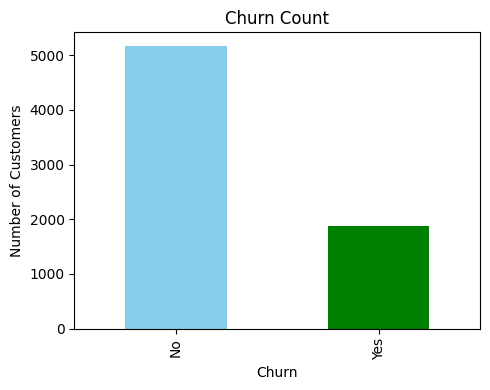

In [9]:
# Visualizations
# Churn distribution
churn_counts = df["Churn"].value_counts()
churn_counts.plot(kind="bar", color=["skyblue", "green"], figsize=(5, 4))
plt.title("Churn Count")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

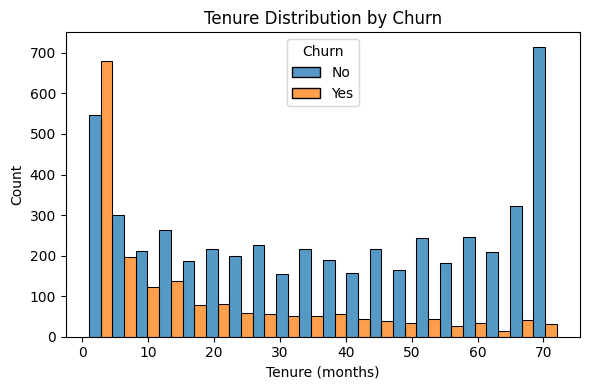

In [10]:
# Tenure by churn
plt.figure(figsize=(6, 4))
sns.histplot(data=df, x="tenure", hue="Churn", bins=20, multiple="dodge")
plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure (months)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_19440\1817943961.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churn", y="MonthlyCharges", palette="Pastel1")


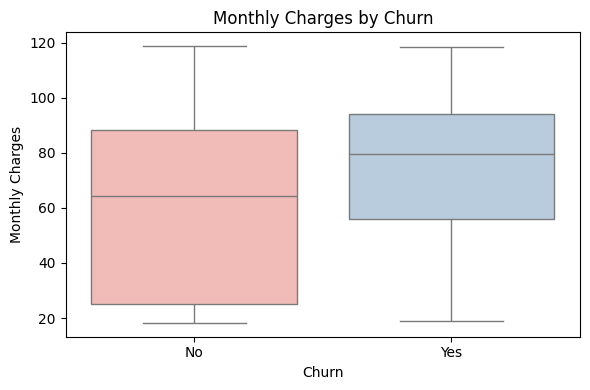

In [11]:
# Monthly charges by churn
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", palette="Pastel1")
plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.tight_layout()
plt.show()

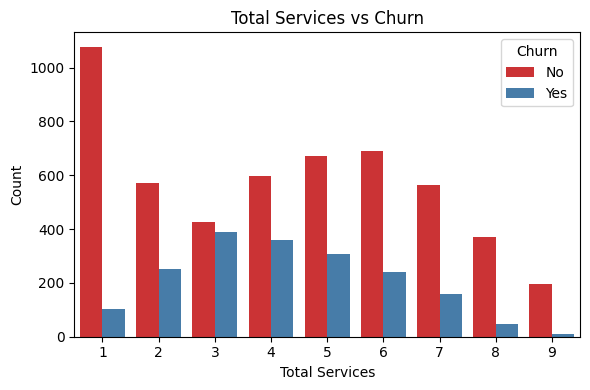

In [12]:
# Total services vs churn
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="TotalServices", hue="Churn", palette="Set1")
plt.title("Total Services vs Churn")
plt.xlabel("Total Services")
plt.ylabel("Count")
plt.legend(title="Churn")
plt.tight_layout()
plt.show()


In [13]:
# Save Cleaned Data

df.to_csv(r"C:\Users\Admin\Downloads\telco-customer-churn-main\Telco-Customer-Churn_Final.csv", index=False)